<a href="https://colab.research.google.com/github/Rahul-lab826/AI-Training/blob/main/Deep_learning_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [29]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train ,x_test = x_train/255.0 , x_test/255.0

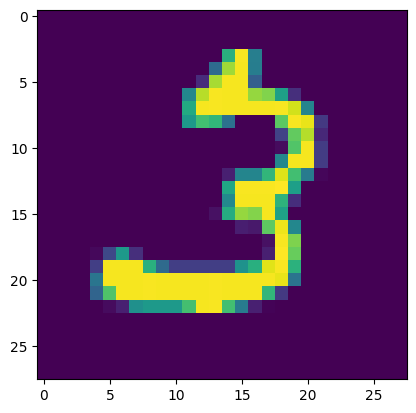

In [30]:
import matplotlib.pyplot as plt
plt.imshow(x_train[59168])

In [71]:
model=keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [32]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [33]:
model.fit(x_train,y_train,validation_split=0.1,epochs=20)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9238 - loss: 0.2682 - val_accuracy: 0.9698 - val_loss: 0.1077
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9663 - loss: 0.1147 - val_accuracy: 0.9722 - val_loss: 0.0915
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9750 - loss: 0.0792 - val_accuracy: 0.9760 - val_loss: 0.0894
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9822 - loss: 0.0589 - val_accuracy: 0.9772 - val_loss: 0.0767
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9755 - val_loss: 0.0789
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9884 - loss: 0.0363 - val_accuracy: 0.9785 - val_loss: 0.0766
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9913 - loss: 0.0281 - val_accuracy: 0.9808 - val_loss: 0.0801
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9928 - loss: 0.0236 

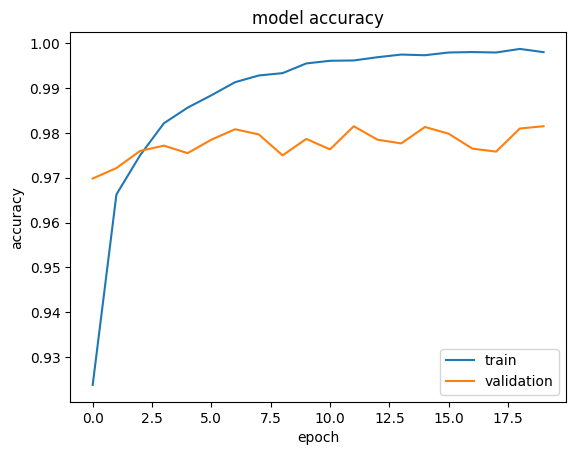

In [34]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

In [36]:
y_pred = model.predict(x_test)
y_pred[8888]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([5.8653623e-14, 3.2415554e-20, 2.1387262e-14, 3.2898362e-15,
       7.7757627e-12, 2.1509250e-18, 9.9999994e-01, 6.7628856e-22,
       6.3549735e-18, 1.1053518e-20], dtype=float32)

In [41]:
import numpy as np
y_pred1=np.argmax(y_pred,axis=1)
y_pred1[6779]

np.int64(0)

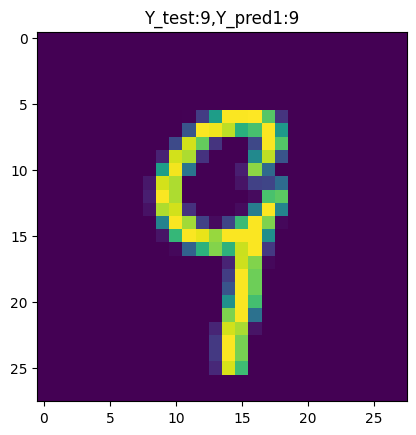

In [51]:
index = 7634

plt.imshow(x_test[index])
plt.title(f"Y_test:{y_test[index]},Y_pred1:{y_pred1[index]}")
plt.show()

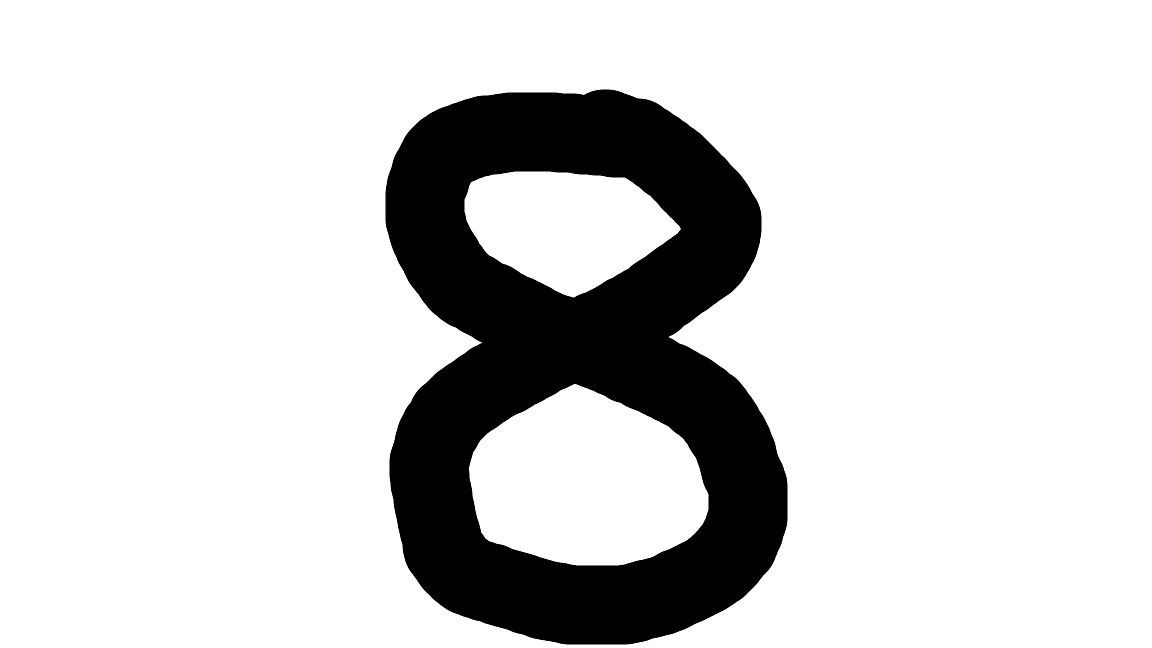

In [90]:
import cv2

img=cv2.imread('/content/7.jpg')
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [91]:
img=cv2.resize(img,(28,28))

In [92]:
img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The model predicted the digit: 8


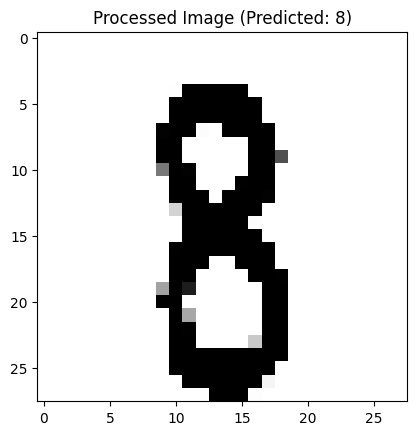

In [93]:

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_resized = cv2.resize(img_gray, (28, 28), interpolation = cv2.INTER_AREA)

img_normalized = img_resized / 255.0

img_processed = img_normalized.reshape(1, 28, 28, 1)

img_tensor_input = tf.constant(img_processed, dtype=tf.float32)

prediction_probabilities = model.predict(img_tensor_input)

y_pred_single_image = np.argmax(prediction_probabilities)

print(f"The model predicted the digit: {y_pred_single_image}")

plt.imshow(img_resized, cmap='gray')
plt.title(f"Processed Image (Predicted: {y_pred_single_image})")
plt.show()

In [73]:
model.save("mnist_model.h5")